# Sprint 1 Baseline Outcome Prediction Pipeline

This notebook demonstrates the initial end-to-end pipeline for explainable process outcome prediction.

Current pipeline stages:
1. Event log loading
2. Outcome labeling
3. Feature encoding
4. Baseline model training
5. Basic evaluation

The current implementation is intended as a first vertical slice ("tracer bullet") and will be refined in later sprints.

## 1. Imports and Project Setup

This section imports the required modules and configures the notebook environment.

In [22]:
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [23]:
from sklearn.model_selection import train_test_split

from src.dataExtraction.extract import import_data
from src.featureEngineering.outcomeLabelling import compute_duration_outcomes, tempFormat
from src.featureEngineering.oneHotFE import Encode
from src.modeling.baseline import train_majority_baseline
from src.modeling.evaluation import compute_basic_metrics

## 2. Event Log Loading

The raw XES event log is loaded and minimally cleaned.
Unnecessary attributes are removed before further processing.

In [24]:
data_path = project_root / "data" / "raw" / "BPI_Challenge_2013_incidents" / "BPI_Challenge_2013_incidents.xes"

drop_columns = ["impact", "org:role"]

df = import_data(str(data_path), drop_columns=drop_columns)
df.head()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 7554/7554 [00:01<00:00, 5864.72it/s]


,org:group,resource country,organization country,org:resource,organization involved,concept:name,product,lifecycle:transition,time:timestamp,case:concept:name
0,V30,France,fr,Frederic,Org line A2,Accepted,PROD582,In Progress,2010-03-31 16:59:42+00:00,1-364285768
1,V30,France,fr,Frederic,Org line A2,Accepted,PROD582,In Progress,2010-03-31 17:00:56+00:00,1-364285768
2,V5 3rd,France,fr,Frederic,Org line A2,Queued,PROD582,Awaiting Assignment,2010-03-31 17:45:48+00:00,1-364285768
3,V5 3rd,France,fr,Anne Claire,Org line A2,Accepted,PROD582,In Progress,2010-04-06 16:44:07+00:00,1-364285768
4,V30,France,fr,Anne Claire,Org line A2,Queued,PROD582,Awaiting Assignment,2010-04-06 16:44:38+00:00,1-364285768


## 3. Outcome Definition and Labeling

A temporary binary outcome definition is used for Sprint 1.

Positive outcome:
- case duration <= median case duration

Negative outcome:
- case duration > median case duration

This definition is primarily intended to create a balanced binary classification task for initial pipeline testing.

In [25]:
from importlib import reload
import src.featureEngineering.outcomeLabelling as outcomeLabelling

reload(outcomeLabelling)

case_outcomes = outcomeLabelling.compute_duration_outcomes(df)

case_outcomes.columns

Index(['case:concept:name', 'case_start', 'case_end', 'duration', 'outcome'], dtype='str')

In [26]:
case_outcomes = compute_duration_outcomes(df)

df_labeled = tempFormat(df, case_outcomes)

df_labeled[["case:concept:name", "concept:name", "outcome"]].head()

,case:concept:name,concept:name,outcome
0,1-364285768,Accepted,0
1,1-364285768,Accepted,0
2,1-364285768,Queued,0
3,1-364285768,Accepted,0
4,1-364285768,Queued,0


## 4. Feature Encoding

The event log is transformed into a case-level feature representation.

Current encoding:
- activity occurrence one-hot encoding
- aggregated numerical statistics

The current implementation ignores activity ordering and serves as a simple baseline feature representation.

In [27]:
X, y, case_ids = Encode(df_labeled, prefix=False)
X.shape, y.shape, len(case_ids)

((7554, 2890), (7554,), 7554)

In [28]:
y.value_counts()

outcome
0    3777
1    3777
Name: count, dtype: int64

## 5. Baseline Model

A majority-class baseline classifier is trained using scikit-learn's `DummyClassifier`.

The baseline always predicts the most frequent class observed in the training data.

In [29]:
X_train, X_test, y_train, y_test, case_ids_train, case_ids_test = train_test_split(
    X,
    y,
    case_ids,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [30]:
baseline_model = train_majority_baseline(X_train, y_train)
baseline_model.classes_

array([0, 1])

In [31]:
y_pred = baseline_model.predict(X_test)
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [32]:
y_proba = baseline_model.predict_proba(X_test)[:, 1]
y_proba[:10]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## 6. Evaluation

The baseline model is evaluated using:
- accuracy
- precision
- recall
- F1 score

Current evaluation uses a simple stratified train/test split and will later be replaced with more process-aware evaluation strategies.

In [33]:
metrics = compute_basic_metrics(y_test, y_pred)
metrics

{'accuracy': 0.499669093315685,
 'f1': 0.6663724624889673,
 'precision': 0.499669093315685,
 'recall': 1.0}

### Baseline Evaluation Interpretation

The majority-class baseline achieves approximately 50% accuracy, which is expected due to the near-balanced outcome distribution created by the median-based labeling strategy.

The model predicts only the majority class, resulting in:
- perfect recall for the positive class,
- low precision,
- and moderate F1 score.

These results establish a minimal reference point for later predictive models.

In [36]:
from src.output.prediction_output import (

    save_prediction_output,

    create_sprint1_visualizations,

)

prediction_output = save_prediction_output(

    case_ids=case_ids_test,

    y_true=y_test,

    predictions=y_pred,

    probabilities=y_proba,

    model_name="majority_baseline",

    output_path="reports/predictions_sprint1.csv",

)

saved_figures = create_sprint1_visualizations(

    prediction_output=prediction_output,

    figures_dir="figures",

)

prediction_output.head(), saved_figures

(       case_id  y_true  prediction  probability              model
 0  1-740610271       1           1          1.0  majority_baseline
 1  1-729748248       0           1          1.0  majority_baseline
 2  1-740760140       1           1          1.0  majority_baseline
 3  1-736499071       0           1          1.0  majority_baseline
 4  1-738448756       1           1          1.0  majority_baseline,
 {'prediction_distribution': PosixPath('figures/prediction_distribution_sprint1.png'),
  'label_distribution': PosixPath('figures/label_distribution_sprint1.png')})

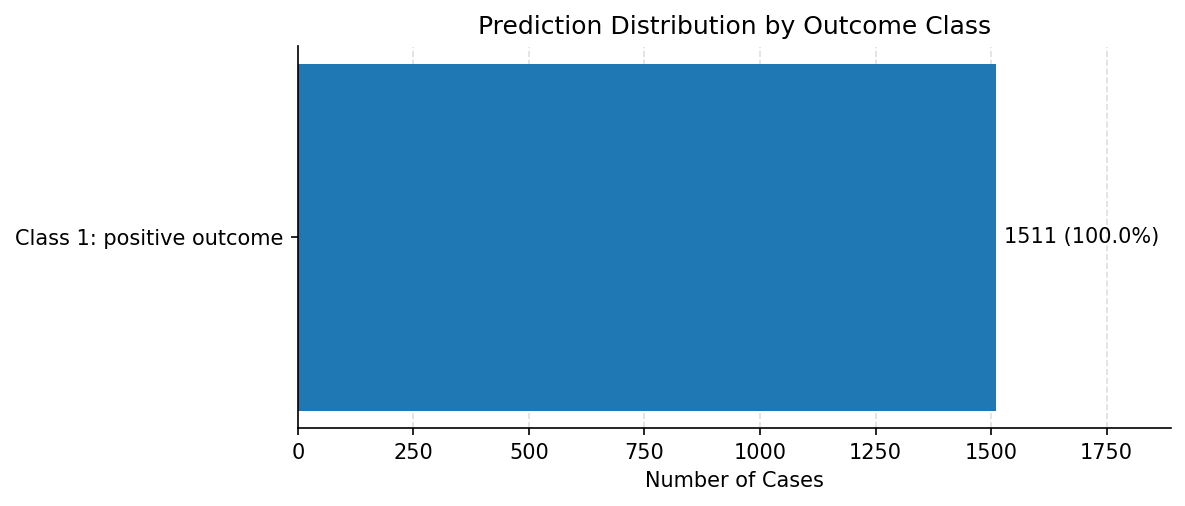

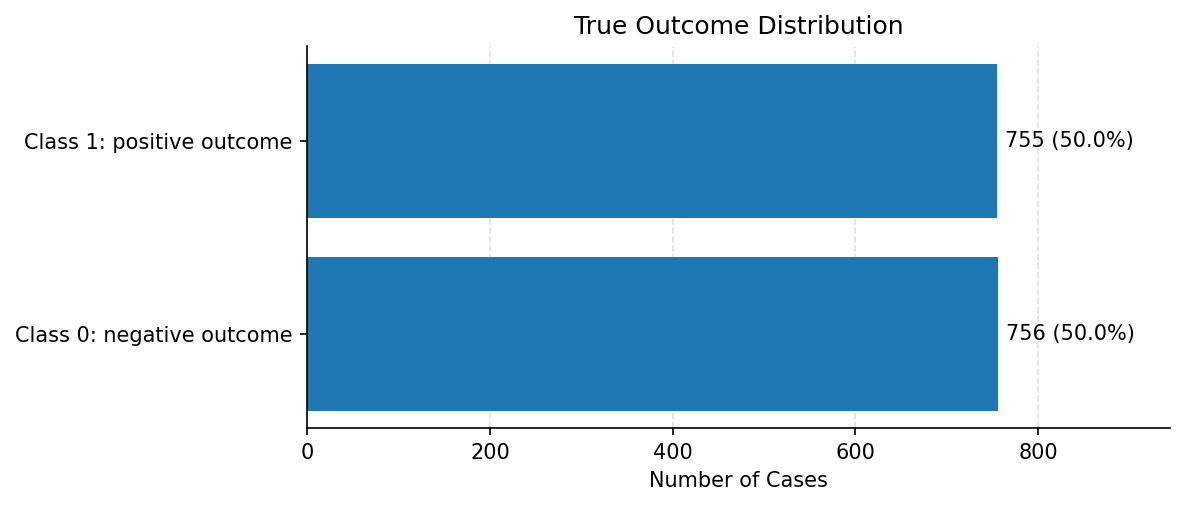

In [35]:
from IPython.display import Image, display

display(Image(filename="figures/prediction_distribution_sprint1.png"))
display(Image(filename="figures/label_distribution_sprint1.png"))